## Code-Struktur

Der gesamte Maschinenraum liegt im Paket [`tep/`](tep) und wird von allen
TEP-Notebooks geteilt. Dieses Notebook enthält nur noch, was es von
seinen Geschwistern unterscheidet: die Konfiguration und die Aufrufe.

| Modul | Inhalt |
|---|---|
| `tep/core.py` | Spaltennamen, Splits, Cutoffs, Vorverarbeitung, lineare Algebra — geteilt mit `tep.tsfresh` |
| `tep/plotting.py` | Confusion-Matrix-Darstellung, ebenfalls geteilt |
| `tep/eigen/config.py` | `SpectrumConfig` — alle Stellschrauben |
| `tep/eigen/data.py` | Trainings-CSVs lesen und zusammenführen |
| `tep/eigen/spectra.py` | Registry der Verfahren: `pca`, `dyca`, `dpca`, `cva`, `ica`, `lda` |
| `tep/eigen/aggregate.py` | Mittelwert/Std je Fehlerklasse, CSV-Export |
| `tep/eigen/plots.py` | die vier Standardplots |
| `tep/eigen/classify.py` | Klassifikation auf den exportierten Spektren |

Ein Verfahren ist ein `Spectrum` mit vier Angaben: Spaltenpräfix,
Klartextname, CSV-Stamm und die Rechnung selbst. Ein eigenes Verfahren
kommt über `tep.eigen.register(...)` dazu, ohne dass hier etwas
angefasst werden muss.

> Die Rechnungen sind zeilengetreu aus der früheren Notebook-Fassung
> übernommen — alle sechs Verfahren wurden vor dem Umbau als
> **bitidentisch** nachgewiesen, ebenso die Spaltennamen und die
> Export-Dateinamen. Die vorhandenen `*_eigenvalues_train*.csv` bleiben
> damit gültig.

## Code-Struktur

Der gesamte Maschinenraum liegt im Paket [`tep/`](tep) und wird von allen
TEP-Notebooks geteilt. Dieses Notebook enthält nur noch, was es von
seinen Geschwistern unterscheidet: die Konfiguration und die Aufrufe.

| Modul | Inhalt |
|---|---|
| `tep/core.py` | Spaltennamen, Splits, Cutoffs, Vorverarbeitung, lineare Algebra — geteilt mit `tep.tsfresh` |
| `tep/plotting.py` | Confusion-Matrix-Darstellung, ebenfalls geteilt |
| `tep/eigen/config.py` | `SpectrumConfig` — alle Stellschrauben |
| `tep/eigen/data.py` | Trainings-CSVs lesen und zusammenführen |
| `tep/eigen/spectra.py` | Registry der Verfahren: `pca`, `dyca`, `dpca`, `cva`, `ica`, `lda` |
| `tep/eigen/aggregate.py` | Mittelwert/Std je Fehlerklasse, CSV-Export |
| `tep/eigen/plots.py` | die vier Standardplots |
| `tep/eigen/classify.py` | Klassifikation auf den exportierten Spektren |

Ein Verfahren ist ein `Spectrum` mit vier Angaben: Spaltenpräfix,
Klartextname, CSV-Stamm und die Rechnung selbst. Ein eigenes Verfahren
kommt über `tep.eigen.register(...)` dazu, ohne dass hier etwas
angefasst werden muss.

> Die Rechnungen sind zeilengetreu aus der früheren Notebook-Fassung
> übernommen — alle sechs Verfahren wurden vor dem Umbau als
> **bitidentisch** nachgewiesen, ebenso die Spaltennamen und die
> Export-Dateinamen. Die vorhandenen `*_eigenvalues_train*.csv` bleiben
> damit gültig.


In [1]:
# ============================================================
# Imports - der gemeinsame Unterbau steckt im Paket tep
# ============================================================
# Wird tep/**.py bearbeitet, muss der Kernel neu gestartet werden;
# alternativ die beiden autoreload-Zeilen aktivieren.
# %load_ext autoreload
# %autoreload 2
import numpy as np
import pandas as pd

from tep.eigen import (aggregate, export, fit_scaler, load_train,
                       merge_faults, plot_bars, plot_cv,
                       plot_means, plot_stds, run_spectra,
                       versions)

print(versions())

/home/annika/Dokumente/Daten/Promotion/06_Code/NicoGrötsch/Hs-Ansbach-CCS/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


tsfresh 0.21.2 | pandas 3.0.3 | numpy 2.4.6 | sklearn 1.9.0 | Kerne: 14


In [2]:
# ============================================================
# Konfiguration - die EINZIGE Stelle, an der geschraubt wird
# ============================================================
# Von hier gehen die Werte als Argumente in die Funktionsaufrufe. Was
# nicht gesetzt wird, bleibt auf dem Default der jeweiligen Funktion
# (pre_fault_cutoff=21, plot_mode='linear', ncols=6, ...).
# RUNS_PER_FAULT=3 kuerzt auf drei Laeufe je Fault - ein Probelauf von
# Minuten statt Stunden.

METHOD = "pca"
SCALING_MODE = "global_mean"
DATA_DIR = "data_csv"           # Ordner mit den vier TEP-CSVs
RUNS_PER_FAULT = None           # None = alle 500 Runs je Fault

# Linienplots zeigen die ersten K_MAX Komponenten von 52.
K_MAX = 25
K_BAR = 10


## Rohdaten laden

Beide Trainings-CSVs werden **einmal** gelesen und zu einem DataFrame zusammengeführt. Der Pre-Fault-Bereich wird erst in der Spektren-Schleife verworfen (`CFG.pre_fault_cutoff = 21`): der Fehler wird 1 h nach Simulationsstart injiziert, bei 3-min-Sampling sind das 20 Samples Vorlauf. Ohne diesen Schnitt würden die ersten 20 Normalbetriebs-Samples die Fault-Statistik verwässern.

In [3]:
# ============================================================
# Rohdaten laden
# ============================================================
# Beide Trainings-CSVs muessen in DATA_DIR liegen. Sie werden EINMAL
# gelesen und zu einem DataFrame (Fault 0..20) zusammengefuehrt; die
# Spektren-Schleife gruppiert daraus nach (fault, run).
df_ff, df_faulty = load_train(data_dir=DATA_DIR,
                              runs_per_fault=RUNS_PER_FAULT)
df_all = merge_faults(df_ff, df_faulty)

# Scaler nur fitten, wenn er auch gebraucht wird (liest 250k Zeilen).
scaler = fit_scaler(METHOD, SCALING_MODE, DATA_DIR)

  lese TEP_FaultFree_Training.csv ...


  lese TEP_Faulty_Training.csv ...


  FaultFree_Training: (250000, 55)
  Faulty_Training   : (5000000, 55)
  Prozessvariablen  : 52


  kombiniert: (5250000, 55), Faults [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20)]


## Spektrum je Lauf

Pro (faultNumber, simulationRun) eine Zerlegung. Das Ergebnis ist eine Zeile je Lauf mit den Werten als Spalten — genau die Form, die auch als CSV exportiert wird.

In [4]:
# ============================================================
# Spektrum je (Fault, Run)
# ============================================================
# Der teure Teil: eine Zerlegung pro Run. Runs, an denen das Verfahren
# numerisch scheitert oder die zu kurz sind, werden gezaehlt und
# uebersprungen - die Meldung darunter sagt wie viele.
per_run = run_spectra(df_all, METHOD, scaling_mode=SCALING_MODE,
                      scaler=scaler)

per_run.head()

Berechne PCA-Spektrum pro Run:   0%|          | 0/10500 [00:00<?, ?it/s]

Berechne PCA-Spektrum pro Run:   0%|          | 1/10500 [00:00<19:52,  8.80it/s]

Berechne PCA-Spektrum pro Run:   0%|          | 3/10500 [00:00<13:26, 13.02it/s]

Berechne PCA-Spektrum pro Run:   0%|          | 6/10500 [00:00<09:30, 18.40it/s]

Berechne PCA-Spektrum pro Run:   0%|          | 9/10500 [00:00<07:57, 21.96it/s]

...

Berechne PCA-Spektrum pro Run: 100%|█████████▉| 10470/10500 [02:01<00:00, 129.82it/s]

Berechne PCA-Spektrum pro Run: 100%|█████████▉| 10486/10500 [02:01<00:00, 136.34it/s]

Berechne PCA-Spektrum pro Run: 100%|██████████| 10500/10500 [02:02<00:00, 86.04it/s] 

Erfolgreiche Runs: 10500
Fehler          : 0


,faultNumber,simulationRun,lambda_1,lambda_2,lambda_3,lambda_4,lambda_5,lambda_6,lambda_7,lambda_8,...,lambda_43,lambda_44,lambda_45,lambda_46,lambda_47,lambda_48,lambda_49,lambda_50,lambda_51,lambda_52
0,0,1,0.547565,0.385752,0.035688,0.018647,0.003760,0.002492,0.002416,0.000842,...,1.609163e-07,5.867784e-08,4.134687e-08,3.899391e-08,2.753374e-08,1.466026e-08,4.404158e-09,2.202548e-09,2.853471e-11,2.731324e-11
1,0,2,0.502700,0.345993,0.083287,0.056964,0.002930,0.002904,0.001837,0.000784,...,1.478494e-07,4.758871e-08,4.161850e-08,2.886628e-08,2.331820e-08,1.784780e-08,3.738598e-09,1.663913e-09,2.353741e-11,2.257079e-11
2,0,3,0.482318,0.376381,0.097897,0.030737,0.003574,0.003171,0.002123,0.000833,...,1.633346e-07,6.049180e-08,4.759535e-08,2.499597e-08,2.120983e-08,1.534228e-08,3.782494e-09,2.163650e-09,2.580545e-11,2.411439e-11
3,0,4,0.501267,0.410513,0.043645,0.032240,0.003551,0.002998,0.002074,0.000737,...,1.618408e-07,5.665111e-08,4.933137e-08,2.858596e-08,2.190300e-08,2.030760e-08,4.365543e-09,1.933532e-09,2.552227e-11,2.416121e-11
4,0,5,0.583539,0.337755,0.043805,0.023277,0.003328,0.002490,0.002129,0.000925,...,1.501767e-07,5.899127e-08,4.911818e-08,3.279287e-08,2.855867e-08,1.436058e-08,3.755965e-09,1.908245e-09,2.624502e-11,2.489031e-11


## Aggregation je Fehlerklasse

Über die 500 Läufe einer Fehlerklasse gemittelt, mit Standardabweichung. pandas rechnet mit `ddof=1` (Stichproben-Std), passend für N = 500.

In [5]:
# ============================================================
# Aggregation: Mittelwert und Standardabweichung je Fehlerklasse
# ============================================================
# Aus einer Zeile je (Fault, Run) wird eine Zeile je Fault mit
# <praefix>i_mean und <praefix>i_std.
agg = aggregate(per_run, METHOD)

agg.head()

Aggregierte PCA-Statistiken pro Fault: (21, 105)


,faultNumber,lambda_1_mean,lambda_1_std,lambda_2_mean,lambda_2_std,lambda_3_mean,lambda_3_std,lambda_4_mean,lambda_4_std,lambda_5_mean,...,lambda_48_mean,lambda_48_std,lambda_49_mean,lambda_49_std,lambda_50_mean,lambda_50_std,lambda_51_mean,lambda_51_std,lambda_52_mean,lambda_52_std
0,0,0.526066,0.027194,0.381317,0.032689,0.051451,0.013719,0.028805,0.008925,0.003413,...,1.624400e-08,3.414908e-09,4.136715e-09,4.604129e-10,1.968460e-09,2.170101e-10,2.665589e-11,2.563557e-12,2.394996e-11,2.425439e-12
1,1,0.624307,0.039010,0.156902,0.012054,0.120917,0.017454,0.084718,0.014229,0.007898,...,4.993505e-09,1.000089e-09,9.112859e-10,1.568663e-10,4.306075e-10,7.433135e-11,5.805388e-12,9.388419e-13,5.220124e-12,8.373813e-13
2,2,0.589118,0.021919,0.234678,0.018968,0.139798,0.012695,0.027692,0.006344,0.004166,...,7.897211e-09,1.076116e-09,1.572852e-09,1.361936e-10,7.179146e-10,6.450928e-11,9.741240e-12,7.331195e-13,8.752344e-12,6.415956e-13
3,3,0.526524,0.027421,0.379323,0.033099,0.052484,0.013943,0.029391,0.009085,0.003390,...,1.614516e-08,3.418773e-09,4.074517e-09,4.593200e-10,1.936356e-09,2.186153e-10,2.622724e-11,2.738421e-12,2.363249e-11,2.519778e-12
4,4,0.526555,0.027362,0.379292,0.033018,0.052474,0.013971,0.029411,0.009098,0.003390,...,1.611223e-08,3.424484e-09,4.074676e-09,4.616040e-10,1.936093e-09,2.178735e-10,2.621042e-11,2.616900e-12,2.350739e-11,2.306880e-12


## Visualisierung

Drei Blickwinkel auf dieselbe Aggregattabelle: das mittlere Niveau, seine Streuung über die Läufe und die dimensionslose relative Streuung. Dazu die ersten Komponenten als Balken mit der Fault-0-Referenz — dort ist am schnellsten zu sehen, welche Komponenten der Fehler wirklich verschiebt.

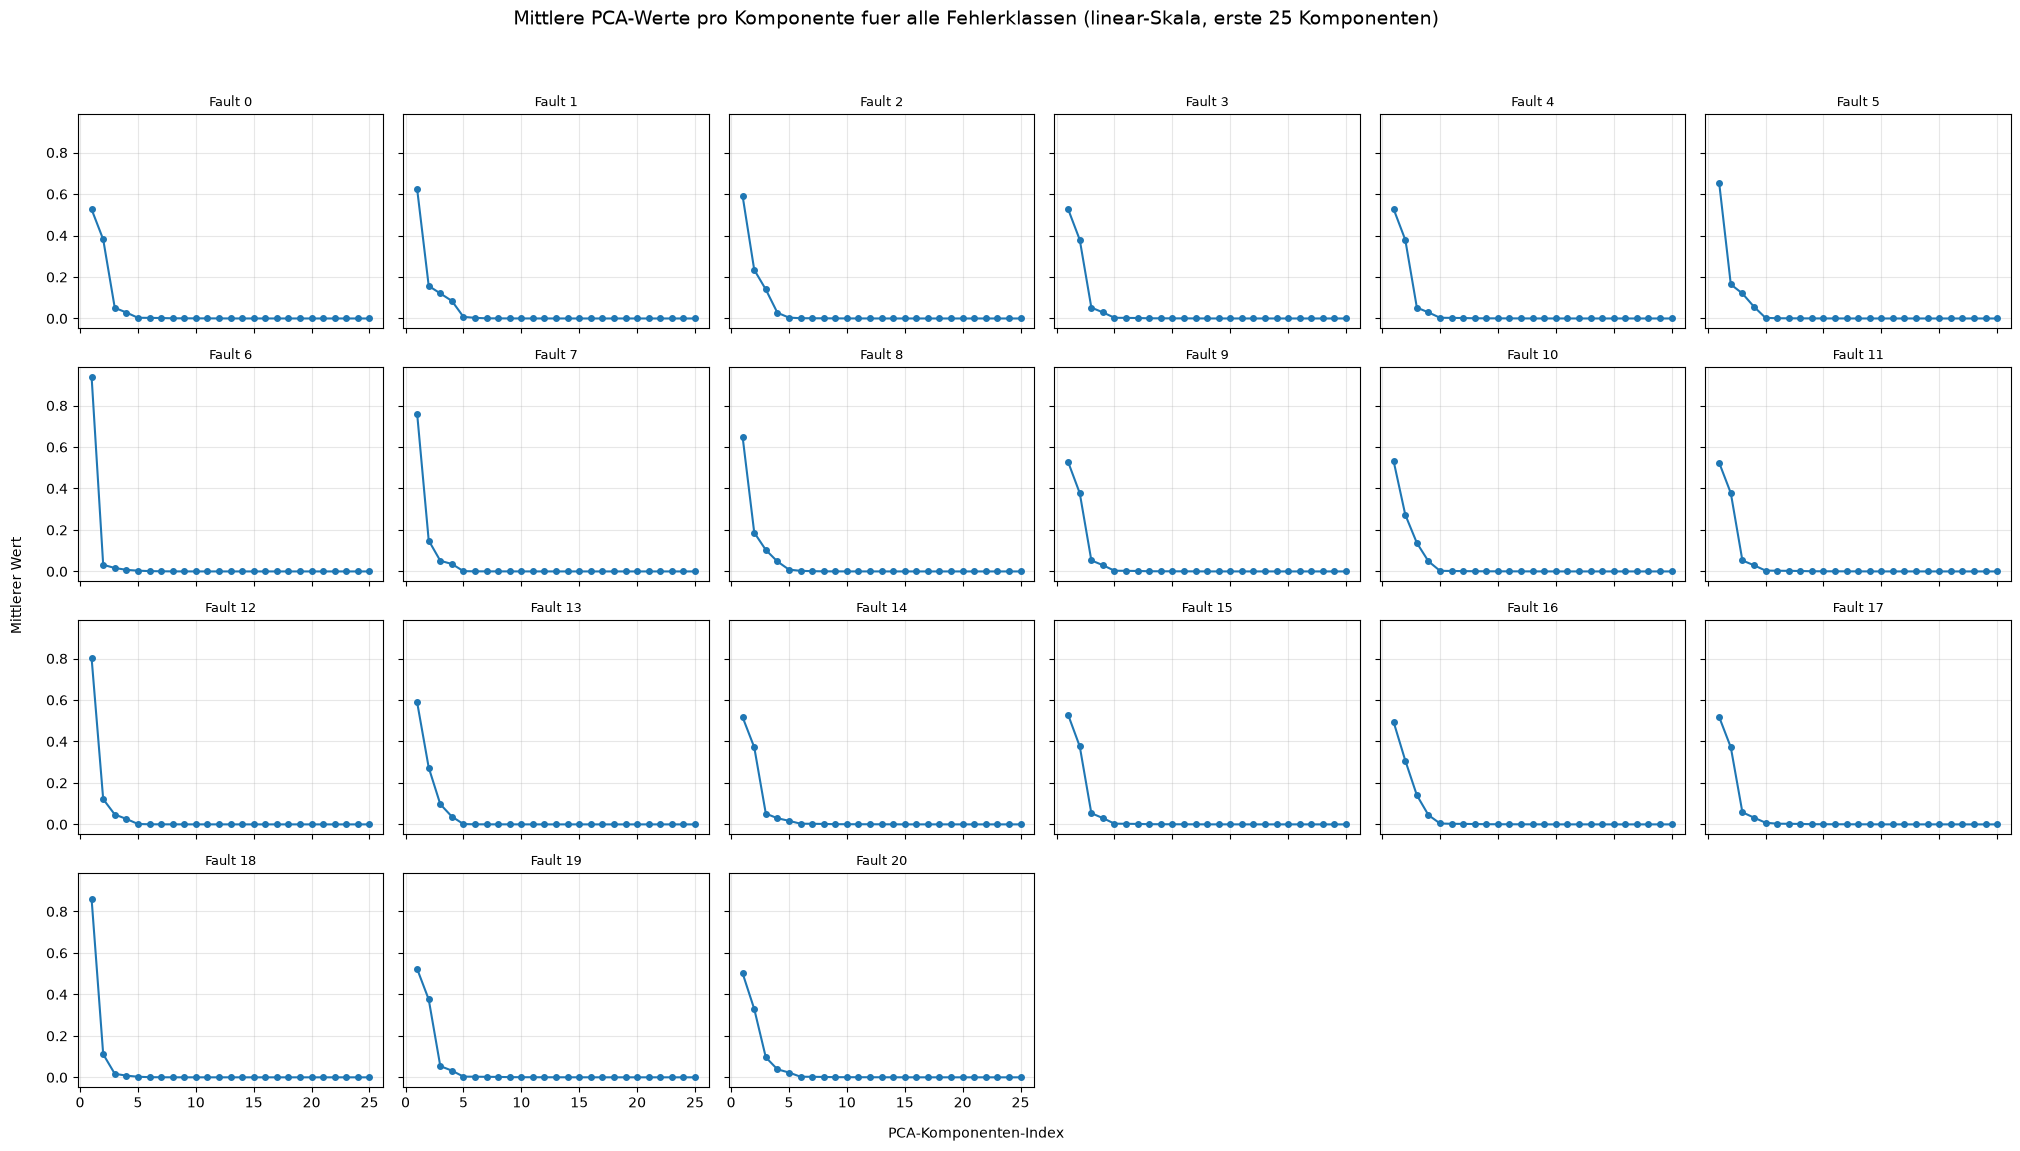

In [6]:
# ============================================================
# Mittleres Spektrum je Fehlerklasse
# ============================================================
# Ein Subplot je Fehlerklasse. Die Darstellungsart steuert plot_mode
# ("linear" | "log" | "relative"), die Zahl der gezeigten Komponenten
# K_MAX.
_ = plot_means(agg, METHOD, k_max=K_MAX)

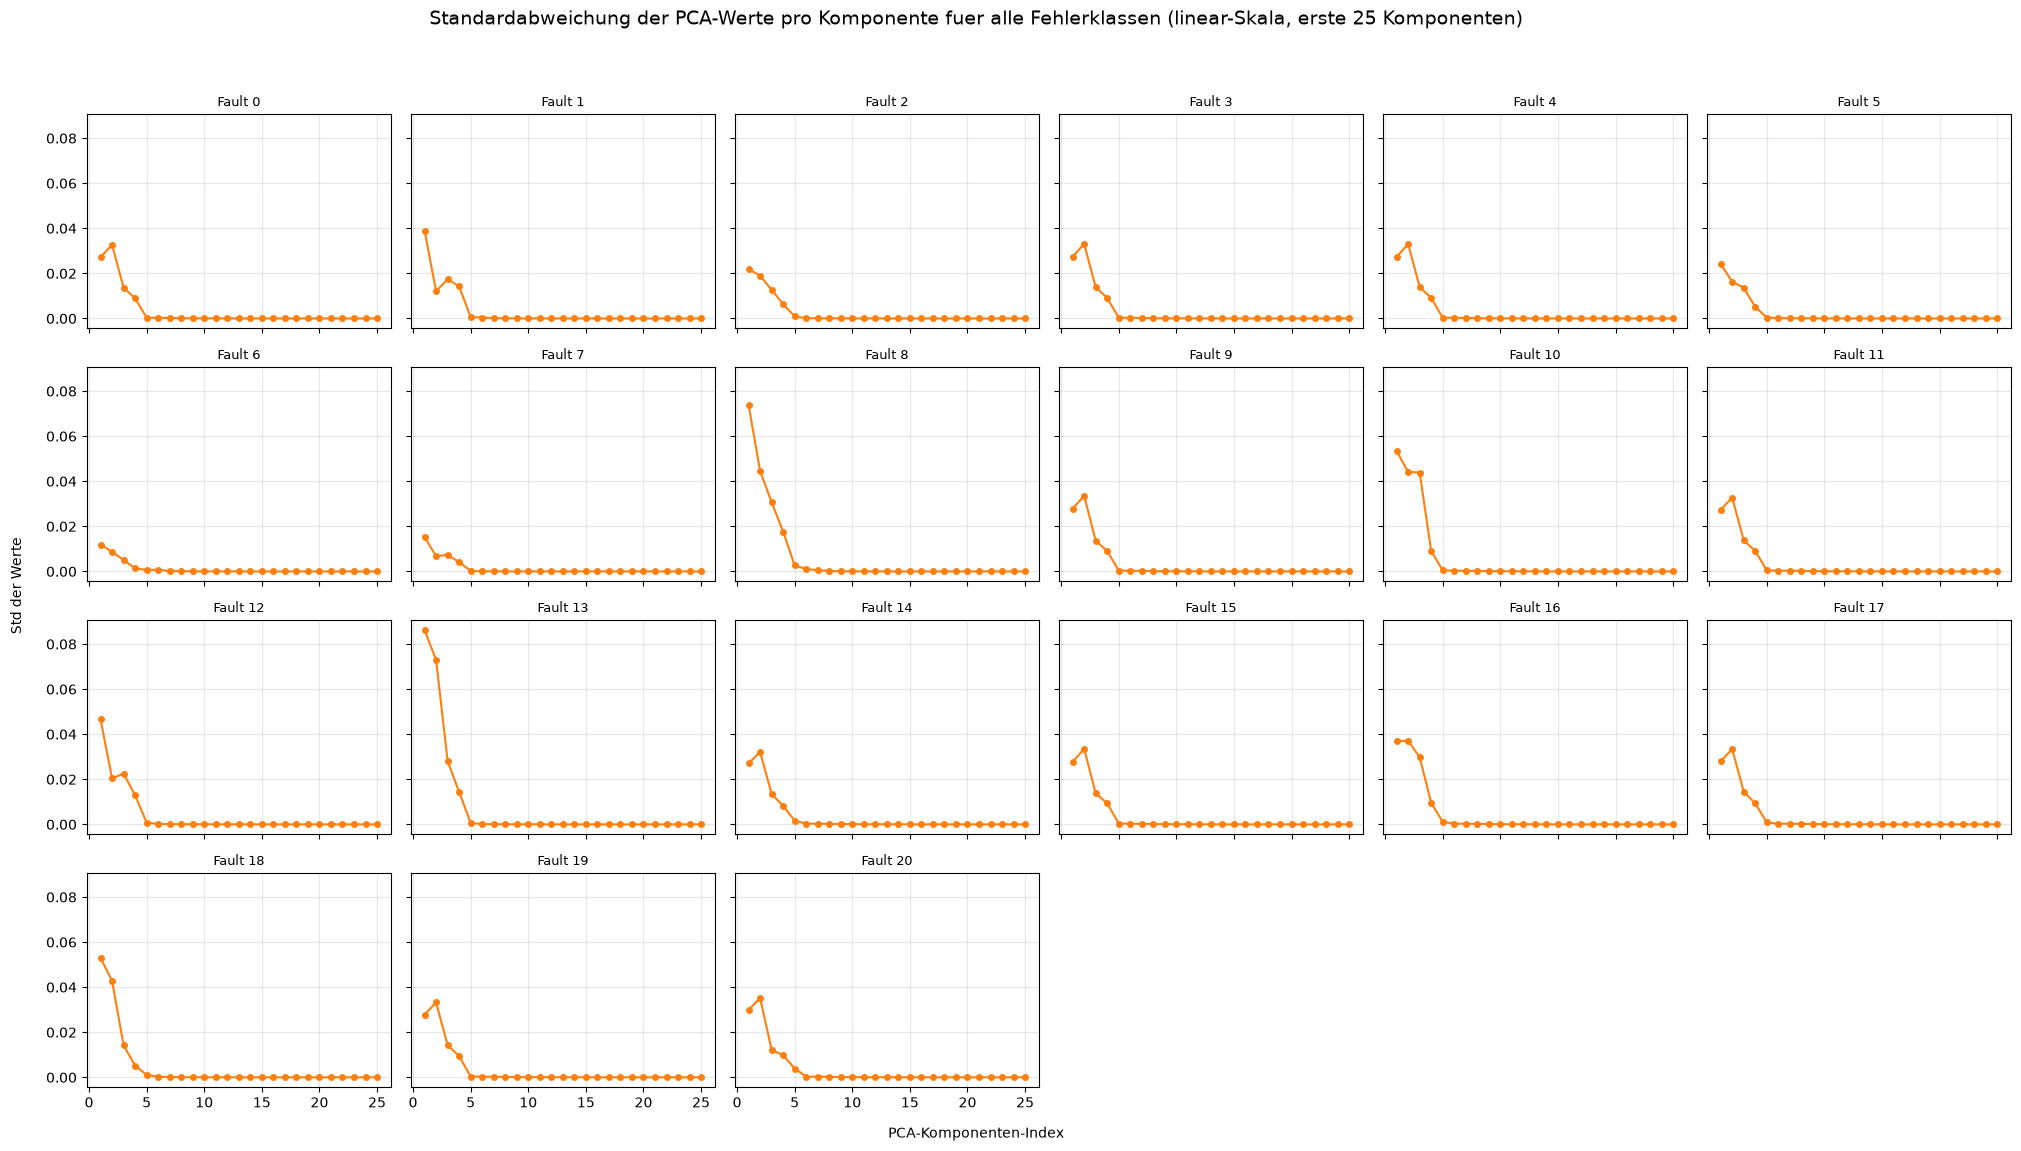

In [7]:
# ============================================================
# Standardabweichung je Komponente
# ============================================================
# Struktur identisch zum Mittelwertsplot. Eine breite Streuung heisst,
# dass die Komponente ueber die Runs einer Klasse nicht stabil ist.
_ = plot_stds(agg, METHOD, k_max=K_MAX)

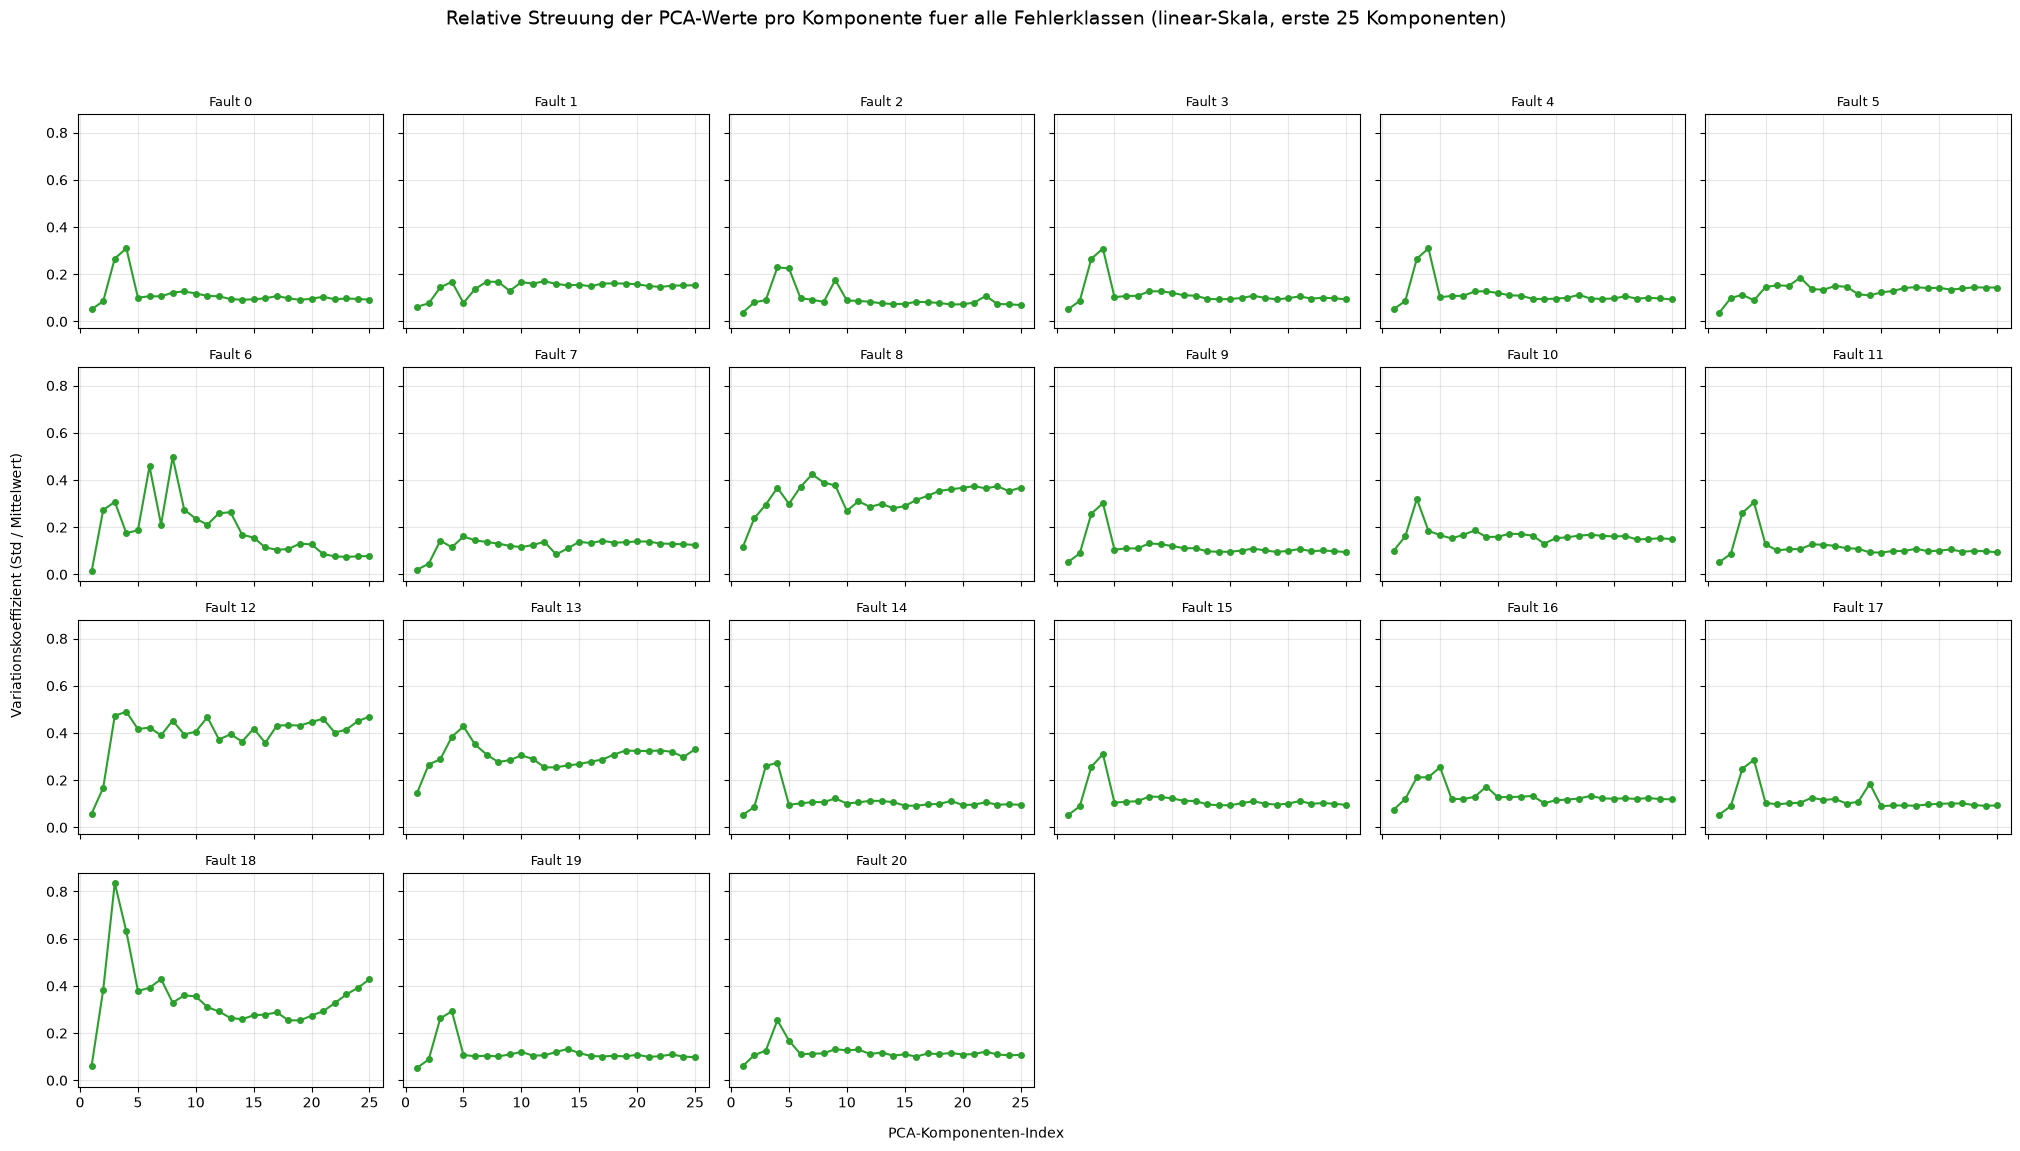

In [8]:
# ============================================================
# Relative Streuung: Variationskoeffizient CV = Std / Mittelwert
# ============================================================
# Dimensionslos und damit ueber Komponenten hinweg vergleichbar, deren
# Absolutniveau um Groessenordnungen auseinanderliegt. Eigener
# Darstellungsmodus ueber plot_mode=... moeglich.
_ = plot_cv(agg, METHOD, k_max=K_MAX)

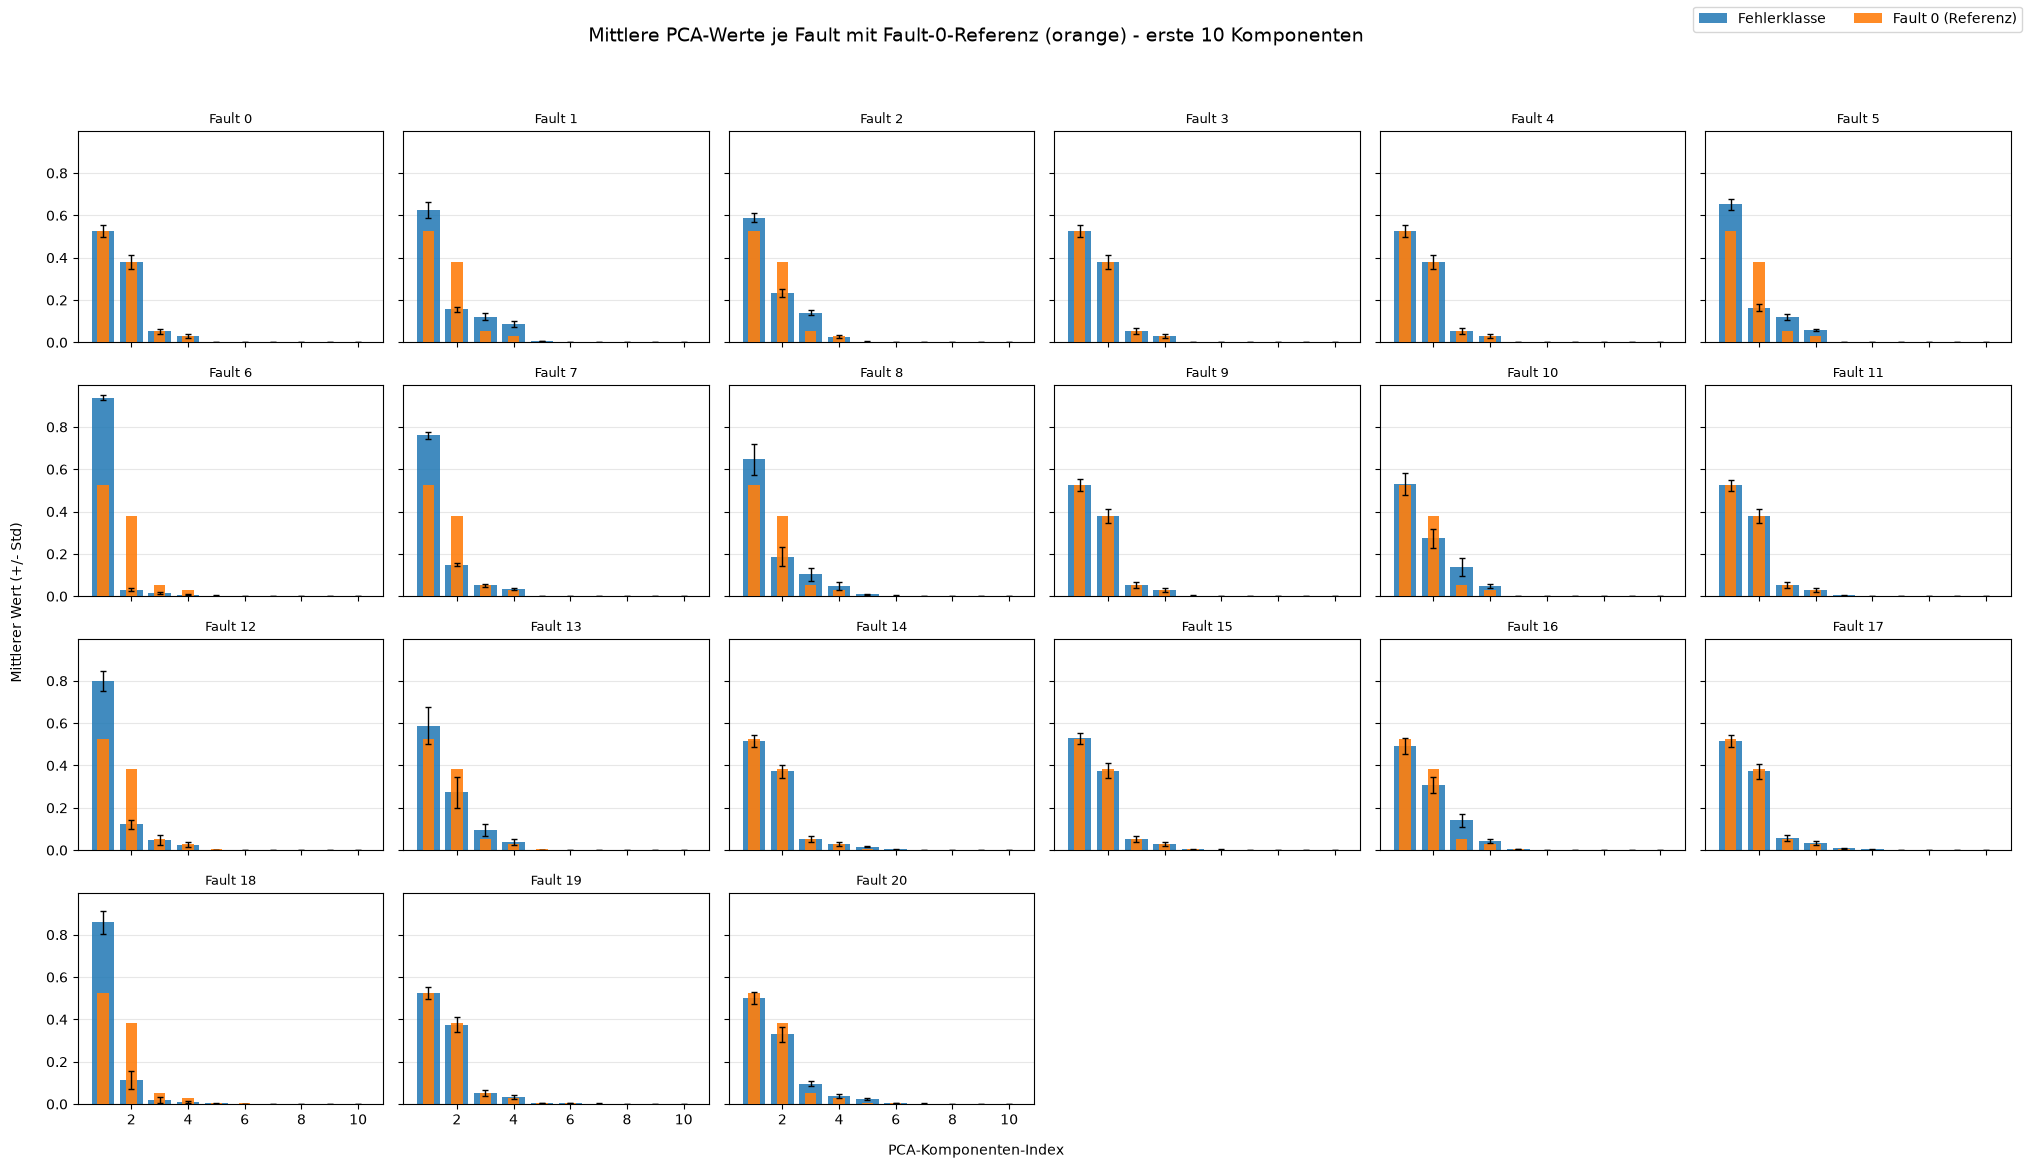

In [9]:
# ============================================================
# Erste k Werte je Fehlerklasse mit Fault-0-Referenz
# ============================================================
# Der schmale orange Balken ist Fault 0 - so ist auf einen Blick zu
# sehen, welche Komponenten sich unter dem Fehler wirklich verschieben.
# Zahl der Balken: K_BAR.
_ = plot_bars(agg, METHOD, k_bar=K_BAR)

## Export der Trainings-Spektren

Schreibt `pca_eigenvalues_train.csv` neben das Notebook. `LazyClassifier_PCA_DyCA.ipynb` liest diese Datei — der Name ist deshalb eingefroren.

In [10]:
# ============================================================
# Export der Trainings-Spektren
# ============================================================
# Stellt sie fuer LazyClassifier_PCA_DyCA.ipynb bereit. Die TEST-Spektren
# werden bewusst NICHT hier berechnet, sondern dort - dieses Notebook
# bleibt training-only. Der Dateiname enthaelt den Skalierungsmodus, ein
# Umschalten ueberschreibt also nichts.
export(per_run, METHOD, SCALING_MODE, DATA_DIR)

PCA-Train gespeichert: (10500, 54) -> data_csv/pca_eigenvalues_train.csv


'data_csv/pca_eigenvalues_train.csv'